In [1]:

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import logging

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from scipy.interpolate import griddata

import jampy as jam
from dynesty import DynamicNestedSampler
from dynesty import plotting as dyplot
from dynesty.pool import Pool
import corner
import os


In [2]:
# import the nested script
import sys
sys.path.append('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/scripts/jampy')
from nested_v4 import *


In [3]:
# now lets load the sampler from the checkpoint file and inspect the results. We will start with the constant beta model, and then move on to the nested beta model.
sampler = DynamicNestedSampler.restore("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/jam_models/free_ml_beta_bh/checkpoint.save")
# print number of samples
print(f"Number of samples: {len(sampler.results.samples)}")

Number of samples: 1699


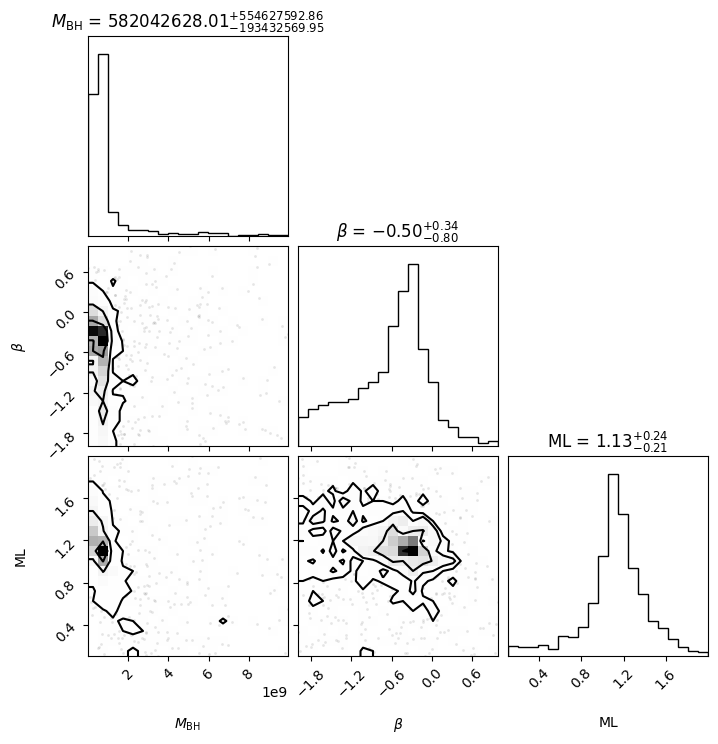

In [ ]:
res = sampler.results.samples
# make corner plot of the results
labels = [r"$M_\mathrm{BH}$", r"$\beta$", r"ML"]

fig = corner.corner(res, labels=labels, show_titles=True)

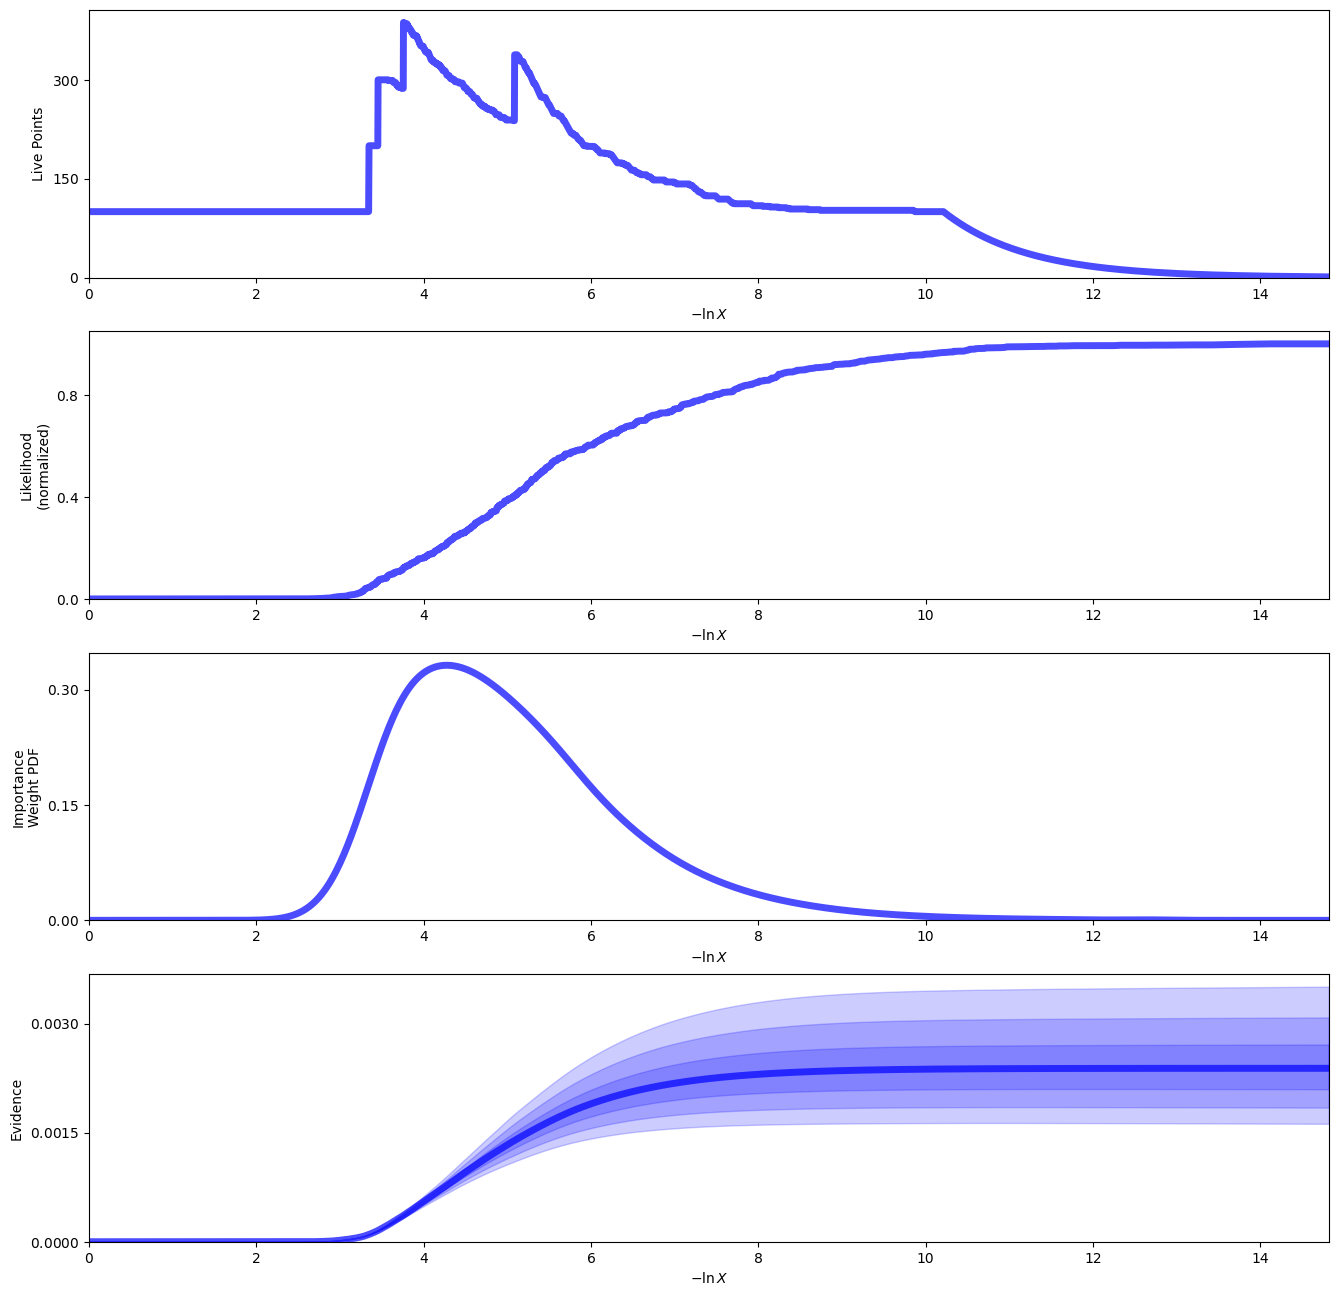

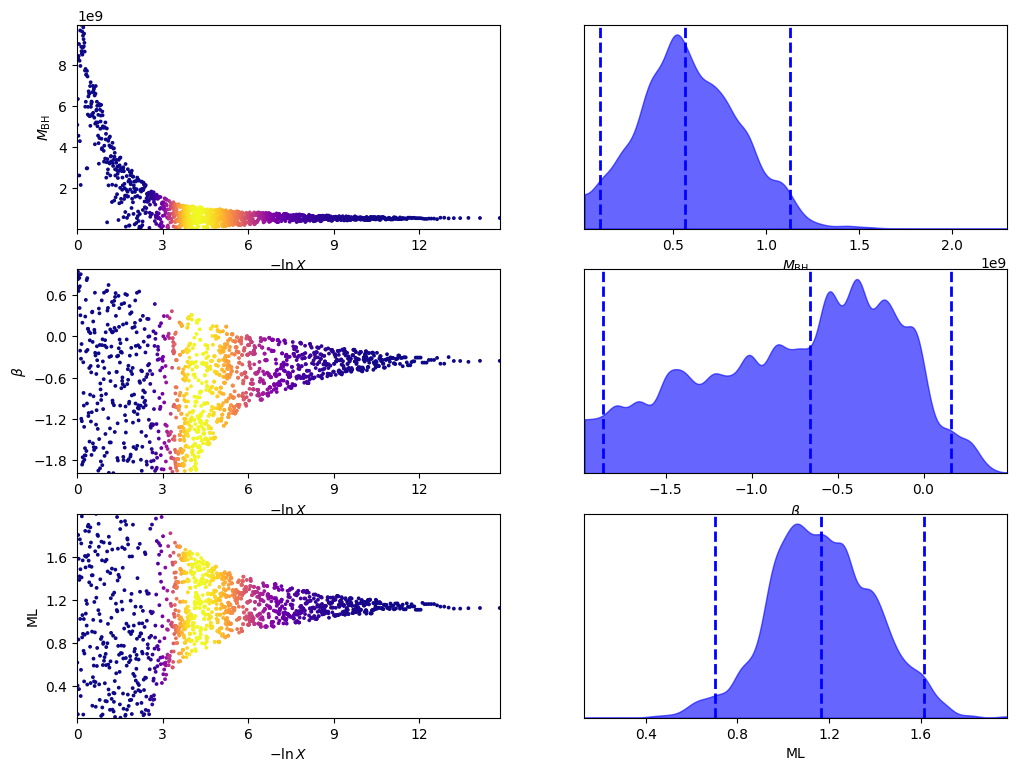

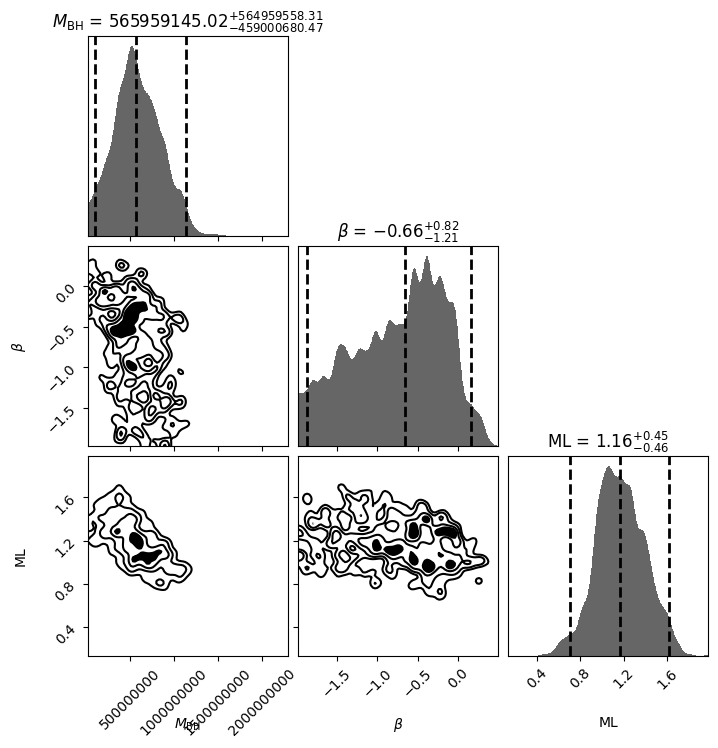

In [10]:
plotdir = '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/jam_models/free_ml_beta_bh'
# make a runplot of the results
fig, axes = dyplot.runplot(sampler.results)
plt.savefig(os.path.join(plotdir, 'runplot.png'), dpi=600)

# make a traceplot of the results
fig, axes = dyplot.traceplot(sampler.results, labels=labels)
plt.savefig(os.path.join(plotdir, 'traceplot.png'), dpi=600)
# make a corner plot of the results
fig, axes = dyplot.cornerplot(sampler.results, labels=labels, show_titles=True)
plt.savefig(os.path.join(plotdir, 'cornerplot.png'), dpi=600)

In [6]:
# make a model of the Vrms field using the best fit parameters
best_fit_params = sampler.results.samples[np.argmax(sampler.results.logl)]
# 
print("Best fit parameters:")
print(f"Black hole mass: {best_fit_params[0]/1e8:.2}e8 Msun")
print(f"Beta: {best_fit_params[1]:.2f}")
print(f"Mass-to-light ratio: {best_fit_params[2]:.2f}")

# THE MEDIAN PARAMETERS
median_params = np.median(sampler.results.samples, axis=0)
print("Median parameters:")
print(f"Black hole mass: {median_params[0]/1e8:.2}e8 Msun")
print(f"Beta: {median_params[1]:.2f}")
print(f"Mass-to-light ratio: {median_params[2]:.2f}")

Best fit parameters:
Black hole mass: 5.3e8 Msun
Beta: -0.36
Mass-to-light ratio: 1.12
Median parameters:
Black hole mass: 5.8e8 Msun
Beta: -0.50
Mass-to-light ratio: 1.13


# Plot model best fit

In [7]:
setup_logging()
cfg = Config()

ensure_output_dir(cfg.output_dir)

logging.info("Loading and preparing kinematics")
kin = load_kinematics(cfg)
save_kinematic_maps(cfg, kin)

logging.info("Loading MGE inputs")
mge = load_mge_inputs(cfg)

logging.info("Building likelihood and priors")
log_likelihood_fn = JamVrmsLogLikelihood(cfg, kin, mge)
prior_transform_fn = UniformPriorTransform(cfg)

2026-04-02 20:29:38,129 | INFO | Loading and preparing kinematics
2026-04-02 20:29:39,430 | INFO | Loading MGE inputs
2026-04-02 20:29:39,435 | INFO | Building likelihood and priors


In [8]:
best_params = get_best_fit_parameters(sampler.results)
losv_model, losv_resid, best_kappa = save_losv_bestfit_plot(cfg, kin, mge, best_params)
vrms_model, vrms_resid = save_vrms_bestfit_plot(cfg, kin, mge, best_params)


# More samples!

In [15]:
# now lets load the sampler from the checkpoint file and inspect the results. We will start with the constant beta model, and then move on to the nested beta model.
sampler = DynamicNestedSampler.restore("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/jam_models/free_ml_beta_bh2/checkpoint.save")
# print number of samples
print(f"Number of samples: {len(sampler.results.samples)}")

Number of samples: 15927


In [16]:
best_params = get_best_fit_parameters(sampler.results)
losv_model, losv_resid, best_kappa = save_losv_bestfit_plot(cfg, kin, mge, best_params)
vrms_model, vrms_resid = save_vrms_bestfit_plot(cfg, kin, mge, best_params)


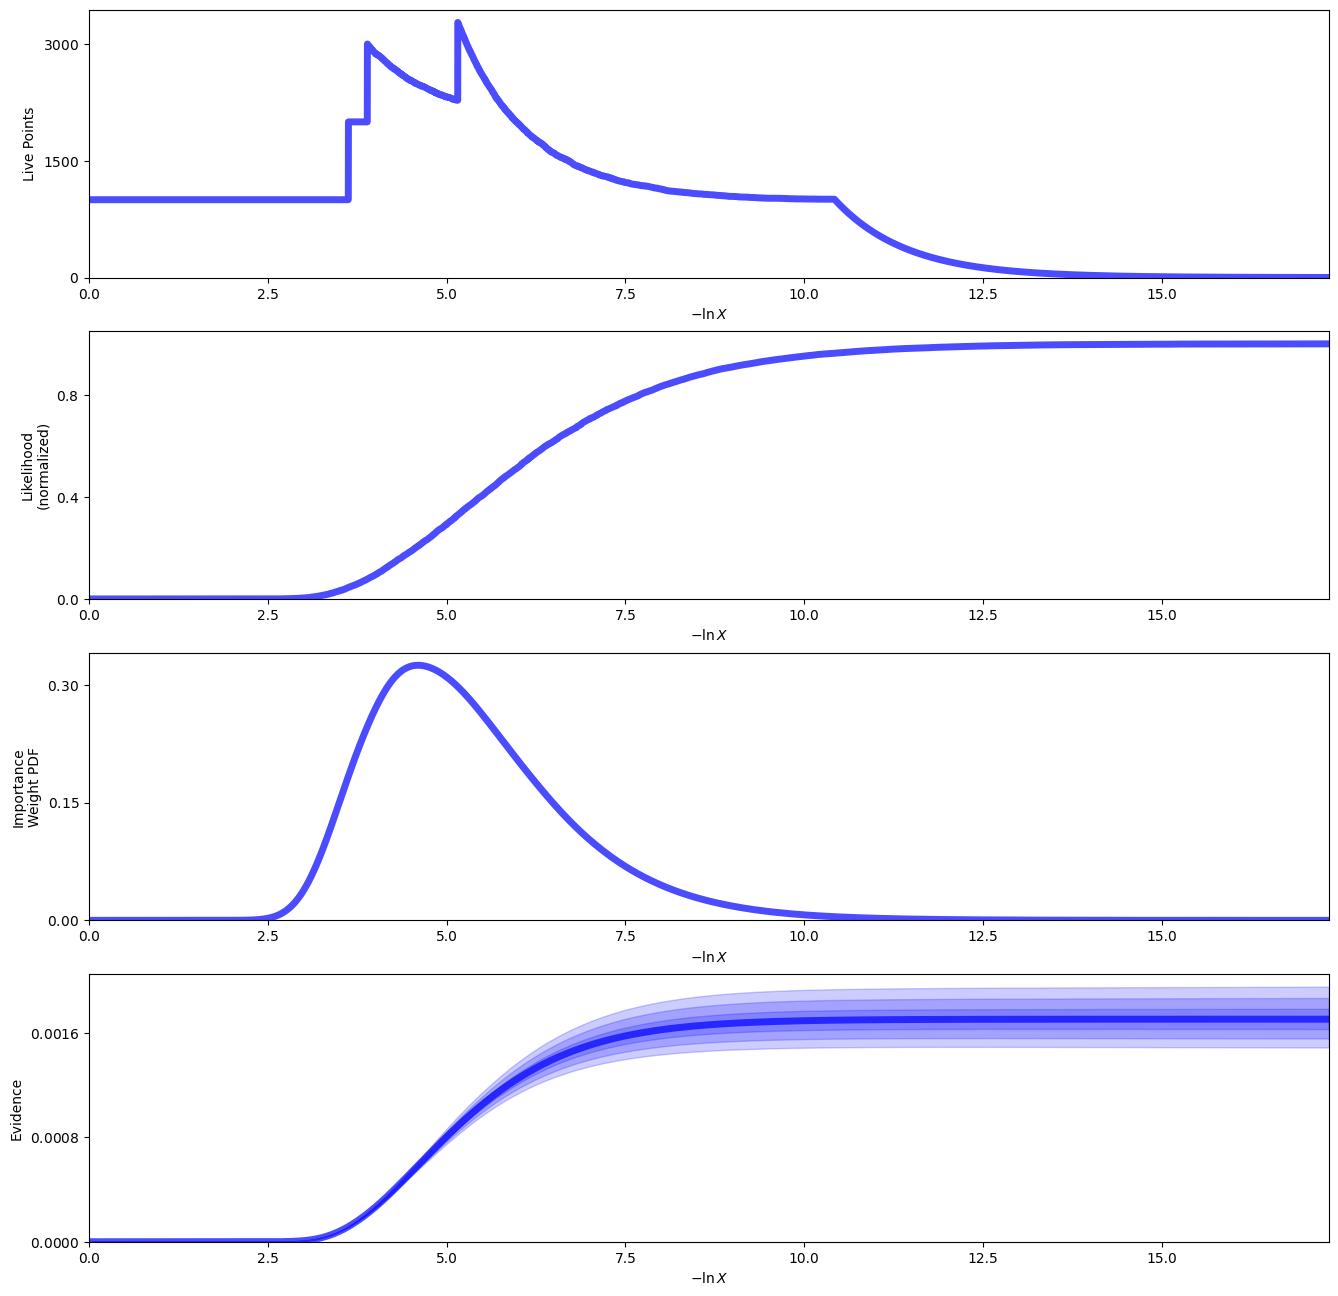

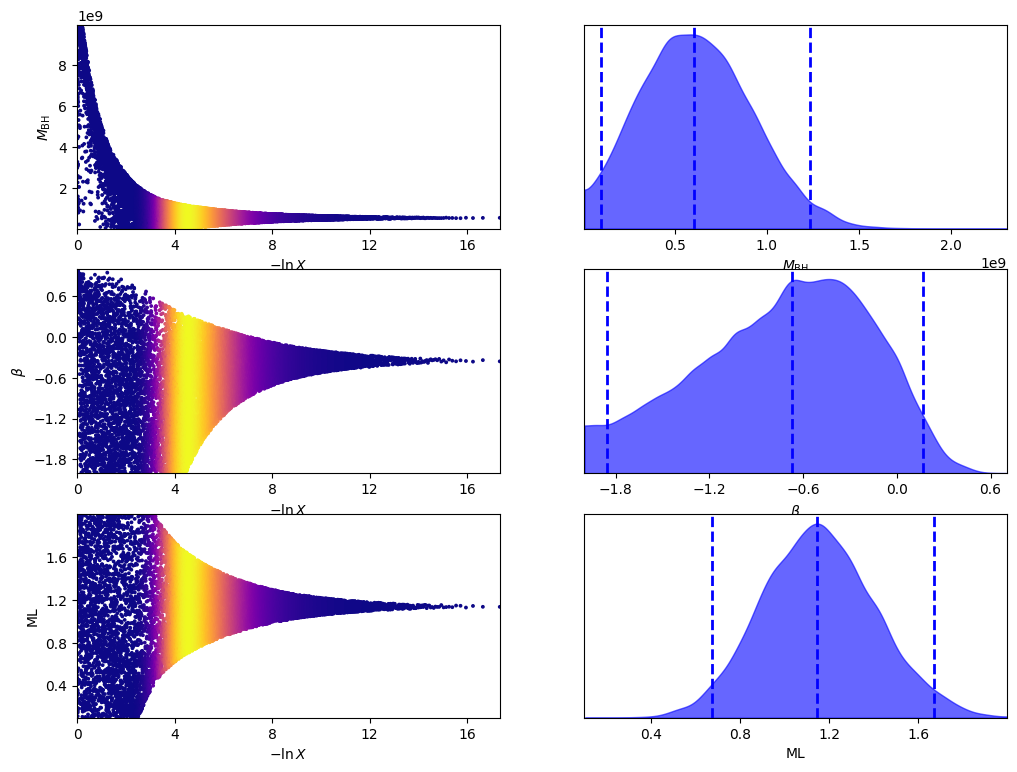

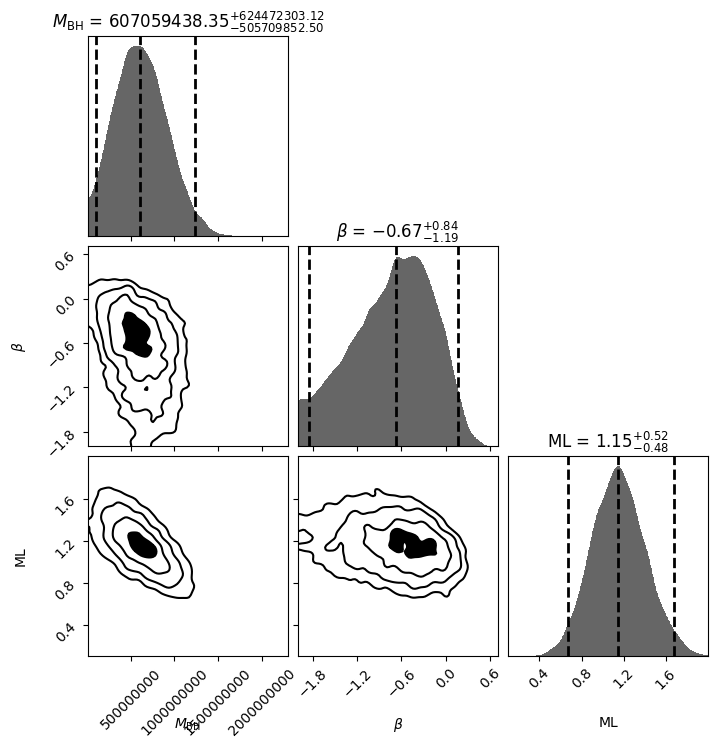

In [17]:
plotdir = '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/jam_models/free_ml_beta_bh2'
# make a runplot of the results
fig, axes = dyplot.runplot(sampler.results)
plt.savefig(os.path.join(plotdir, 'runplot.png'), dpi=600)

# make a traceplot of the results
fig, axes = dyplot.traceplot(sampler.results, labels=labels)
plt.savefig(os.path.join(plotdir, 'traceplot.png'), dpi=600)
# make a corner plot of the results
fig, axes = dyplot.cornerplot(sampler.results, labels=labels, show_titles=True)
plt.savefig(os.path.join(plotdir, 'cornerplot.png'), dpi=600)

In [18]:
best_params

array([ 5.36378990e+08, -3.62269948e-01,  1.13341927e+00])

# With logistic

In [ ]:
from nested_free import *